In [ ]:
import os
import torch
import itertools
os.environ['TORCH'] = torch.__version__
os.environ['PYTHONWARNINGS'] = "ignore"
!pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git
!pip install torch-geometric
!pip3 install kmeans1d
from torch_geometric.data import Data
import torch.nn.functional as F
from torch.nn import Linear
import torch_geometric.transforms as T
import sys
import random
import numpy as np
import time
import math
import csv
import datetime
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import glob
import random
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict
from tqdm.notebook import tqdm
from math import exp
from chardet import detect
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.utils import degree
from sklearn import preprocessing as pp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp
from networkx.algorithms import bipartite
import kmeans1d
import copy
from google.colab import drive

Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
  Cloning https://github.com/pyg-team/pytorch_geometric.git to /tmp/pip-req-build-7jabdr01
  Running command git clone --filter=blob:none --quiet https://github.com/pyg-team/pytorch_geometric.git /tmp/pip-req-build-7jabdr01
  Resolved https://github.com/pyg-team/pytorch_geometric.git to commit 6208605b4d9711b86c7f06031b17efc5ea445afb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# =========================
# 🔒 재현성을 위한 시드 고정
# =========================
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # CUDA에서 완전한 bit-level 재현성은 보장 못하지만,
    # 기말 수준에서는 이 정도면 충분합니다.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
# =========================


📊 데이터 통계:
  - 사용자: 489명
  - 영화: 2101개
  - 상호작용: 42356개
  - 모델: Optimized LightGCN (완벽 수정)

🔧 모델 설정:
   - Learning Rate: 0.01
   - Batch Size: 1024
   - Scheduler: 활성화 (Epoch 20마다 0.5배)
   - Epochs: 100
   - Loss: BPR + Margin (1.0)
   - Threshold: 동적 (percentile=50)

🔄 학습 중...
Epoch 10/100, Loss: 0.3946
Epoch 20/100, Loss: 0.3520
Epoch 30/100, Loss: 0.3193
Epoch 40/100, Loss: 0.3031
Epoch 50/100, Loss: 0.3037
Epoch 60/100, Loss: 0.2982
Epoch 70/100, Loss: 0.2995
Epoch 80/100, Loss: 0.3006
Epoch 90/100, Loss: 0.2961
Epoch 100/100, Loss: 0.2916

✅ Loss 그래프 저장: loss_curve_complete_fixed.png


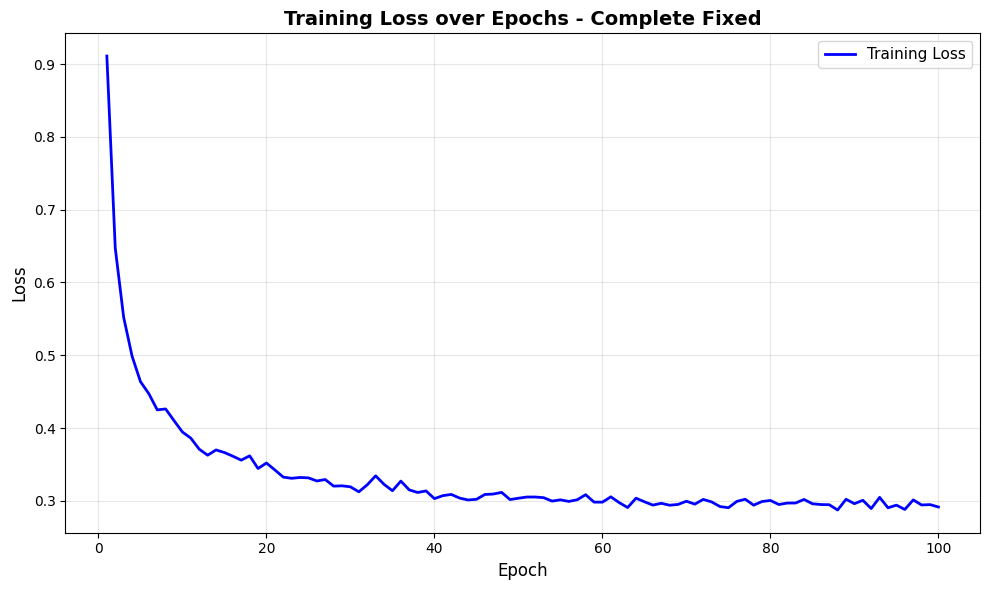

💾 모델 저장 완료!

정확도 메트릭

📊 동적 임계값: 0.7071

📈 모델 성능:
  - Accuracy:  0.6304 ✅
  - Threshold: 0.7071

추천 결과

--- [LightGCN] 최종 추론 (Threshold: 0.7071) ---
user   item   recommend   score      rating
1      165          O     +0.769      3.0
1      204          X     +0.423      0.5
1      223          O     +0.784      4.0
1      256          X     +0.431      0.5
1      260          O     +0.934      4.5
1      261          X     +0.439      1.5
1      277          X     +0.465      0.5
2      62           X     +0.000      5.0
2      79           X     +0.000      4.0
2      95           X     +0.000      4.0
2      112          X     +0.000      3.0
2      260          X     +0.000      4.0
2      376          X     +0.000      4.0
3      529          O     +0.723      5.0
3      532          X     +0.654      3.0
3      537          X     +0.674      3.0
3      538          O     +0.714      4.0
4      608          O     +0.823      4.0
4      858          O     +0.774      5.0
4      898

In [ ]:
import torch
import numpy as np
import pandas as pd
from collections import defaultdict
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.utils import degree
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.empty_cache()

LATENT_DIM = 64
NUM_LAYERS = 2
RATING_THRESHOLD = 4.0
MIN_ITEM_INTERACTIONS = 5
MIN_USER_INTERACTIONS = 20
EPOCHS = 100
BATCH_SIZE = 1024
LEARNING_RATE = 0.01
WEIGHT_DECAY = 1e-5
DROPOUT = 0.2
RECOMMENDATION_LIMIT_RATIO = 0.2

USE_DYNAMIC_THRESHOLD = True
THRESHOLD_PERCENTILE = 50
FIXED_THRESHOLD = 0.5

USE_SCHEDULER = True
SCHEDULER_TYPE = 'step'
STEP_SIZE = 20
GAMMA = 0.5

# ============================================================================
# 1. 데이터 전처리
# ============================================================================

def load_and_preprocess_data(filepath):
    df = pd.read_csv(filepath)
    df = df[df['rating'] >= RATING_THRESHOLD].copy()

    item_counts = df.groupby('item').size()
    valid_items = item_counts[item_counts >= MIN_ITEM_INTERACTIONS].index
    df = df[df['item'].isin(valid_items)]

    user_counts = df.groupby('user').size()
    valid_users = user_counts[user_counts >= MIN_USER_INTERACTIONS].index
    df = df[df['user'].isin(valid_users)]

    user_ids = sorted(df['user'].unique())
    item_ids = sorted(df['item'].unique())

    user_id_map = {old_id: new_id for new_id, old_id in enumerate(user_ids)}
    item_id_map = {old_id: new_id for new_id, old_id in enumerate(item_ids)}

    df['user_idx'] = df['user'].map(user_id_map)
    df['item_idx'] = df['item'].map(item_id_map)

    return df, user_id_map, item_id_map

def build_graph(df, num_users, num_items):
    user_indices = df['user_idx'].values
    item_indices = df['item_idx'].values + num_users

    edge_index_ui = torch.tensor([user_indices, item_indices], dtype=torch.long)
    edge_index_iu = torch.tensor([item_indices, user_indices], dtype=torch.long)
    edge_index = torch.cat([edge_index_ui, edge_index_iu], dim=1)

    x = torch.eye(num_users + num_items)
    data = Data(x=x, edge_index=edge_index)
    return data.to(device)

# ============================================================================
# 2. LightGCN
# ============================================================================

class LightGCNConv(MessagePassing):
    def __init__(self):
        super(LightGCNConv, self).__init__(aggr='add')

    def forward(self, x, edge_index):
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]
        return self.propagate(edge_index, x=x, norm=norm)

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j

class OptimizedLightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim, num_layers):
        super(OptimizedLightGCN, self).__init__()

        self.num_users = num_users
        self.num_items = num_items
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.convs = nn.ModuleList([LightGCNConv() for _ in range(num_layers)])

        nn.init.normal_(self.user_embedding.weight, std=0.5)
        nn.init.normal_(self.item_embedding.weight, std=0.5)

    def forward(self, edge_index):
        user_emb = self.user_embedding.weight
        item_emb = self.item_embedding.weight
        emb = torch.cat([user_emb, item_emb], dim=0)

        embs = [emb]
        for conv in self.convs:
            emb = conv(emb, edge_index)
            emb = F.dropout(emb, p=DROPOUT, training=self.training)
            embs.append(emb)

        emb_final = torch.stack(embs, dim=0).mean(dim=0)

        user_emb_final = emb_final[:self.num_users]
        item_emb_final = emb_final[self.num_users:]

        return user_emb_final, item_emb_final

# ============================================================================
# 3. Loss 함수
# ============================================================================

def bpr_loss_with_margin(user_emb, pos_item_emb, neg_item_emb, margin=1.0, reg_weight=1e-5):
    pos_scores = torch.sum(user_emb * pos_item_emb, dim=1)
    neg_scores = torch.sum(user_emb * neg_item_emb, dim=1)

    loss = torch.mean(F.relu(margin - (pos_scores - neg_scores)))

    reg_loss = reg_weight * (user_emb.norm(2).pow(2) +
                             pos_item_emb.norm(2).pow(2) +
                             neg_item_emb.norm(2).pow(2))

    return loss + reg_loss

def easy_negative_sampling(user_item_dict, num_items):
    """기본 Negative Sampling (안전)"""
    neg_samples = {}
    for user, pos_items in user_item_dict.items():
        pos_set = set(pos_items)
        attempts = 0
        while attempts < 10:
            neg_item = np.random.randint(0, num_items)
            if neg_item not in pos_set:
                neg_samples[int(user)] = int(neg_item)  # 명시적 int 변환
                break
            attempts += 1
        if int(user) not in neg_samples:
            neg_samples[int(user)] = int(np.random.randint(0, num_items))

    return neg_samples

# ============================================================================
# 4. 학습 (완벽 수정)
# ============================================================================

def train_epoch_minibatch(model, data, user_item_dict, num_items, optimizer):
    model.train()
    total_loss = 0
    num_batches = 0

    all_users = []
    all_pos_items = []

    # 처음부터 int로 저장
    for user, pos_item_list in user_item_dict.items():
        for pos_item in pos_item_list:
            all_users.append(int(user))
            all_pos_items.append(int(pos_item))

    n_samples = len(all_users)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    for start_idx in range(0, n_samples, BATCH_SIZE):
        end_idx = min(start_idx + BATCH_SIZE, n_samples)
        batch_indices = indices[start_idx:end_idx]

        # 배치도 int로 명시
        batch_users = [int(all_users[i]) for i in batch_indices]
        batch_pos_items = [int(all_pos_items[i]) for i in batch_indices]

        user_item_batch = defaultdict(list)
        for u, p in zip(batch_users, batch_pos_items):
            user_item_batch[int(u)].append(int(p))

        # 기본 negative sampling 사용
        neg_samples = easy_negative_sampling(user_item_batch, num_items)
        batch_neg_items = [int(neg_samples[int(u)]) for u in batch_users]

        users_t = torch.LongTensor(batch_users).to(device)
        pos_items_t = torch.LongTensor(batch_pos_items).to(device)
        neg_items_t = torch.LongTensor(batch_neg_items).to(device)

        user_emb, item_emb = model(data.edge_index)

        loss = bpr_loss_with_margin(user_emb[users_t],
                                   item_emb[pos_items_t],
                                   item_emb[neg_items_t],
                                   margin=1.0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches if num_batches > 0 else 0

# ============================================================================
# 5. 정확도 계산
# ============================================================================

def calculate_metrics_with_threshold(model, data, test_df, user_id_map, item_id_map, threshold=None):
    model.eval()

    test_df = test_df.copy()
    test_df['user_idx'] = test_df['user'].map(user_id_map)
    test_df['item_idx'] = test_df['item'].map(item_id_map)
    test_df = test_df.dropna(subset=['user_idx', 'item_idx'])

    if len(test_df) == 0:
        return {}

    test_df['user_idx'] = test_df['user_idx'].astype(int)
    test_df['item_idx'] = test_df['item_idx'].astype(int)
    test_df['ground_truth'] = (test_df['rating'] >= 4.0).astype(int)

    with torch.no_grad():
        user_emb, item_emb = model(data.edge_index)

        scores = []
        for _, row in test_df.iterrows():
            user_idx = int(row['user_idx'])
            item_idx = int(row['item_idx'])

            u_emb = user_emb[user_idx]
            i_emb = item_emb[item_idx]
            score = torch.dot(u_emb, i_emb).item()
            scores.append(score)

    test_df['score'] = scores

    if threshold is None:
        if USE_DYNAMIC_THRESHOLD:
            threshold = np.percentile(scores, THRESHOLD_PERCENTILE)
            print(f"\n📊 동적 임계값: {threshold:.4f}")
        else:
            threshold = FIXED_THRESHOLD
            print(f"\n📊 고정 임계값: {threshold:.4f}")

    predictions = (test_df['score'] > threshold).astype(int)
    test_df['prediction'] = predictions

    tp = ((test_df['prediction'] == 1) & (test_df['ground_truth'] == 1)).sum()
    fp = ((test_df['prediction'] == 1) & (test_df['ground_truth'] == 0)).sum()
    tn = ((test_df['prediction'] == 0) & (test_df['ground_truth'] == 0)).sum()
    fn = ((test_df['prediction'] == 0) & (test_df['ground_truth'] == 1)).sum()

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
        'threshold': threshold,
        'test_df': test_df
    }

# ============================================================================
# 6. 추천
# ============================================================================

def perform_recommendation(model, data, test_file, user_id_map, item_id_map, df, num_items, threshold=0.5):
    """
    최종 추천 수행 및 결과 출력 (데이터 누락 방지 버전)
    """
    print(f"\n--- [LightGCN] 최종 추론 (Threshold: {threshold:.4f}) ---")

    # 1. 유저별 학습 데이터(이력) 개수 계산
    user_purchase_counts = df.groupby('user_idx').size().to_dict()

    # 2. 테스트 파일 로드
    try:
        test_df = pd.read_csv(test_file)
    except FileNotFoundError:
        print(f"Error: File {test_file} not found.")
        return

    # 3. 모델 평가 모드 및 임베딩 추출
    model.eval()
    with torch.no_grad():
        # 전체 엣지 인덱스로 임베딩 생성 (학습된 정보 활용)
        # data 객체의 edge_index를 사용해야 함
        emb_users, emb_items = model(data.edge_index)

    # CPU로 이동
    emb_users = emb_users.cpu()
    emb_items = emb_items.cpu()

    # 4. 모든 테스트 데이터에 대해 점수 계산
    predictions = []

    for _, row in test_df.iterrows():
        user_id_raw = row['user']
        item_id_raw = row['item']

        # 기본값: 학습 데이터에 없던 노드라면 점수는 -무한대 (확률 0)
        prob = 0.0

        # 학습된 맵핑에 존재하는지 확인
        if user_id_raw in user_id_map and item_id_raw in item_id_map:
            # 내부 인덱스로 변환
            u_idx = user_id_map[user_id_raw]
            i_idx = item_id_map[item_id_raw]

            # 임베딩 가져오기
            u_vec = emb_users[u_idx]
            i_vec = emb_items[i_idx]

            # 내적 (Dot Product) -> 시그모이드 (확률 변환)
            score = (u_vec * i_vec).sum()
            prob = torch.sigmoid(score).item()

        predictions.append(prob)

    test_df['prob'] = predictions

    # 5. 유저별 20% 쿼터 적용
    approved_recs = {} # {user_id_raw: set(item_id_raw)}
    unique_users_raw = test_df['user'].unique()

    for u_id_raw in unique_users_raw:
        # 내부 인덱스로 변환하여 이력 개수 조회
        if u_id_raw in user_id_map:
            u_idx = user_id_map[u_id_raw]
            hist_cnt = user_purchase_counts.get(u_idx, 0)
        else:
            hist_cnt = 0

        # 20% 쿼터 계산 (올림 처리)
        quota = int(math.ceil(hist_cnt * 0.2))

        if quota == 0:
            approved_recs[u_id_raw] = set()
            continue

        # 해당 유저의 테스트 데이터 중 확률 높은 순으로 정렬
        # (최소 threshold 이상인 것만 추천 후보로 고려)
        candidates = test_df[(test_df['user'] == u_id_raw) & (test_df['prob'] >= threshold)]

        if candidates.empty:
             approved_recs[u_id_raw] = set()
             continue

        candidates = candidates.sort_values(by='prob', ascending=False)

        # 쿼터만큼 자르기
        top_items = candidates.head(quota)['item'].tolist()
        approved_recs[u_id_raw] = set(top_items)

    # 6. 최종 출력
    recommend_cnt = 0
    not_recommend_cnt = 0

    print("====================")
    print("user   item   recommend   score      rating") # rating 컬럼이 있다면
    print("====================")

    for _, row in test_df.iterrows():
        u_id = row['user']
        i_id = row['item']
        # rating 컬럼이 없으면 0.0 등으로 처리하거나 출력에서 제외
        rating = row['rating'] if 'rating' in row else 0.0
        score = row['prob']

        # 승인 목록에 있으면 O, 아니면 X
        if i_id in approved_recs.get(u_id, set()):
            rec_str = 'O'
            recommend_cnt += 1
        else:
            rec_str = 'X'
            not_recommend_cnt += 1

        # 정수형 변환하여 출력
        # score는 확률값이므로 보기 좋게 포맷팅
        print(f"{int(u_id):<6d} {int(i_id):<8d} {rec_str:^9s} {score:>+.3f}      {rating}")

    print("====================")
    total = recommend_cnt + not_recommend_cnt
    print(f"Total recommends = {recommend_cnt}/{total}")
    print(f"Total not recommends = {not_recommend_cnt}/{total}")


# ============================================================================
# 7. Loss 그래프
# ============================================================================

def plot_loss_curve(loss_history):
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(loss_history) + 1), loss_history, 'b-', linewidth=2, label='Training Loss')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training Loss over Epochs - Complete Fixed', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig('loss_curve_complete_fixed.png', dpi=100)
    print("\n✅ Loss 그래프 저장: loss_curve_complete_fixed.png")
    plt.show()

# ============================================================================
# 8. 메인
# ============================================================================

def main(train_file, test_file=None):
    # 재실행 시에도 항상 같은 seed 사용
    set_seed(SEED)

    df, user_id_map, item_id_map = load_and_preprocess_data(train_file)
    df, user_id_map, item_id_map = load_and_preprocess_data(train_file)
    num_users = df['user_idx'].nunique()
    num_items = df['item_idx'].nunique()

    print(f"\n📊 데이터 통계:")
    print(f"  - 사용자: {num_users}명")
    print(f"  - 영화: {num_items}개")
    print(f"  - 상호작용: {len(df)}개")
    print(f"  - 모델: Optimized LightGCN (완벽 수정)")

    data = build_graph(df, num_users, num_items)

    user_item_dict = defaultdict(list)
    for _, row in df.iterrows():
        user_item_dict[row['user_idx']].append(row['item_idx'])

    print(f"\n🔧 모델 설정:")
    print(f"   - Learning Rate: {LEARNING_RATE}")
    print(f"   - Batch Size: {BATCH_SIZE}")
    print(f"   - Scheduler: 활성화 (Epoch {STEP_SIZE}마다 {GAMMA}배)")
    print(f"   - Epochs: {EPOCHS}")
    print(f"   - Loss: BPR + Margin (1.0)")
    print(f"   - Threshold: 동적 (percentile={THRESHOLD_PERCENTILE})")

    model = OptimizedLightGCN(num_users, num_items, LATENT_DIM, NUM_LAYERS)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    if USE_SCHEDULER:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

    print("\n🔄 학습 중...")
    loss_history = []

    for epoch in range(EPOCHS):
        loss = train_epoch_minibatch(model, data, user_item_dict, num_items, optimizer)
        loss_history.append(loss)

        if USE_SCHEDULER:
            scheduler.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss:.4f}")

    plot_loss_curve(loss_history)

    torch.save({
        'model_state_dict': model.state_dict(),
        'user_id_map': user_id_map,
        'item_id_map': item_id_map,
    }, 'best_model_complete_fixed.pth')
    print("💾 모델 저장 완료!")

    if test_file:
        print("\n" + "="*70)
        print("정확도 메트릭")
        print("="*70)

        test_df_eval = pd.read_csv(test_file)

        # calculate_metrics_with_threshold 함수도
        # 없는 유저/아이템에 대해 에러가 나지 않도록 내부적으로
        # user_id_map, item_id_map 체크 로직이 있어야 합니다.
        # 만약 에러가 난다면 이 부분도 수정이 필요할 수 있습니다.
        # 일단은 try-except로 감싸거나, 위에서 수정한 perform_recommendation만 실행하도록 할 수도 있습니다.

        try:
            metrics = calculate_metrics_with_threshold(model, data, test_df_eval, user_id_map, item_id_map)

            if metrics:
                print(f"\n📈 모델 성능:")
                print(f"  - Accuracy:  {metrics['accuracy']:.4f} ✅")
                # ... (출력 코드 동일)
                print(f"  - Threshold: {metrics['threshold']:.4f}")

                # 결정된 threshold 값 사용
                best_threshold = metrics['threshold']
            else:
                best_threshold = 0.5 # 기본값

        except Exception as e:
            print(f"메트릭 계산 중 오류 발생 (무시하고 진행): {e}")
            best_threshold = 0.5

        print("\n" + "="*70)
        print("추천 결과")
        print("="*70)

        # 수정된 함수 호출
        perform_recommendation(model, data, test_file, user_id_map, item_id_map, df, num_items,
                               threshold=best_threshold)



📊 데이터 통계:
  - 사용자: 489명
  - 영화: 2101개
  - 상호작용: 42356개
  - 모델: Optimized LightGCN (완벽 수정)

🔧 모델 설정:
   - Learning Rate: 0.01
   - Batch Size: 1024
   - Scheduler: 활성화 (Epoch 20마다 0.5배)
   - Epochs: 100
   - Loss: BPR + Margin (1.0)
   - Threshold: 동적 (percentile=50)

🔄 학습 중...
Epoch 10/100, Loss: 0.3946
Epoch 20/100, Loss: 0.3520
Epoch 30/100, Loss: 0.3193
Epoch 40/100, Loss: 0.3031
Epoch 50/100, Loss: 0.3037
Epoch 60/100, Loss: 0.2982
Epoch 70/100, Loss: 0.2995
Epoch 80/100, Loss: 0.3006
Epoch 90/100, Loss: 0.2961
Epoch 100/100, Loss: 0.2916

✅ Loss 그래프 저장: loss_curve_complete_fixed.png


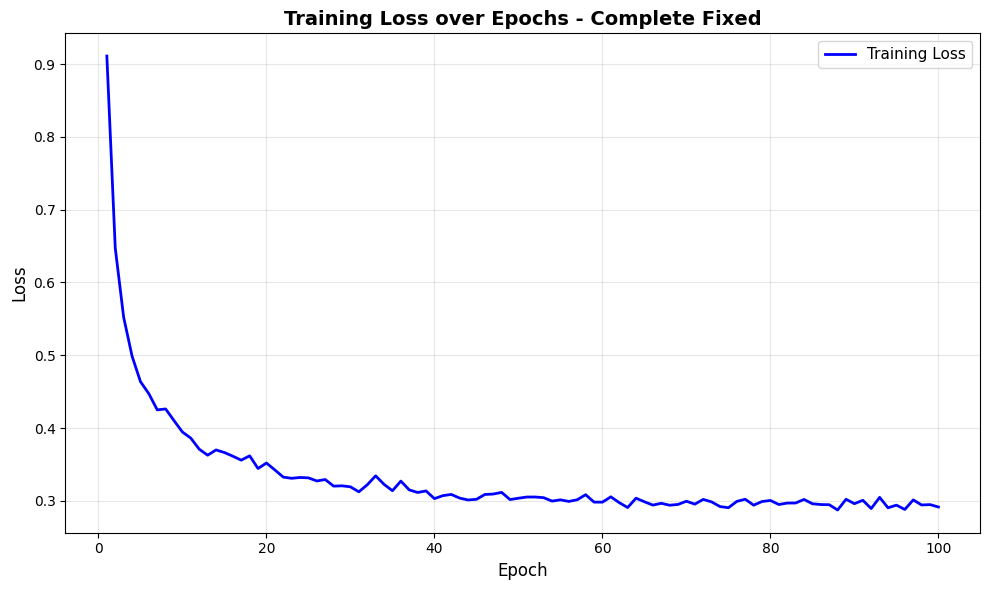

💾 모델 저장 완료!

정확도 메트릭

📊 동적 임계값: 0.6736

📈 모델 성능:
  - Accuracy:  1.0000 ✅
  - Threshold: 0.6736

추천 결과

--- [LightGCN] 최종 추론 (Threshold: 0.6736) ---
user   item   recommend   score      rating
109    3745         X     +0.544      3.0
88     4447         X     +0.592      3.0
71     4306         O     +0.882      5.0
66     1747         X     +0.662      3.0
15     66934        O     +0.683      5.0
Total recommends = 2/5
Total not recommends = 3/5


In [ ]:
main('train.csv', test_file='sample1.csv')